## Selección y Justificación de Variables

En esta etapa se realizó la carga de los datasets HISTORICO_SUERTES.xlsx y BD_IPSA_1940.xlsx, los cuales contienen información histórica de producción de caña de azúcar y variables asociadas al cultivo.

Para facilitar el manejo de rutas dentro del proyecto, se utilizó la librería Path, permitiendo una estructura reproducible y organizada.

Posteriormente, se verificaron las dimensiones de cada dataset con el fin de entender el tamaño y complejidad de los datos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Rutas
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DIR = BASE_DIR / "data" / "raw"

# Cargar datos
historico = pd.read_excel(RAW_DIR / "HISTORICO_SUERTES.xlsx")
ipsa = pd.read_excel(RAW_DIR / "BD_IPSA_1940.xlsx")

# Ver dimensiones
print("Historico:", historico.shape)
print("IPSA:", ipsa.shape)

Historico: (21027, 85)
IPSA: (2187, 21)


Para la tarea de regresión, cuyo objetivo es predecir las variables TCH y %Sac.Caña, se realizó una selección de variables basada en el conocimiento del negocio adquirido en la fase anterior.

Inicialmente, se consideraron variables como Edad Ult Cos, Variedad, Suelo, Area Neta, Num.Riegos, %Infest.Diatrea, Dosis Madurante, Semanas mad. y TonUltCorte, ya que representan factores clave relacionados con características del cultivo, manejo agronómico y rendimiento histórico.

Sin embargo, durante el análisis exploratorio de datos se identificó que algunas de estas variables presentaban un alto porcentaje de valores faltantes, especialmente %Infest.Diatrea, Num.Riegos y Semanas mad., por lo que fueron eliminadas del análisis para evitar sesgos en el modelo.

Asimismo, se detectó una alta correlación entre Area Neta y TonUltCorte, lo que indicaba redundancia de información. Por esta razón, se decidió eliminar Area Neta, manteniendo TonUltCorte como variable representativa del rendimiento.

Finalmente, se trabajó con un conjunto depurado de variables que incluyen Edad Ult Cos, Variedad, Suelo, Dosis Madurante y TonUltCorte, las cuales aportan información relevante y consistente para la predicción.

Por otro lado, se descartaron variables como Nombre, Cod.Estado y Periodo, debido a que funcionan como identificadores y no tienen poder predictivo.

In [9]:
variables_regresion = [
    "Edad Ult Cos",
    "Variedad",
    "Suelo",
    "Area Neta",
    "Num.Riegos",
    "%Infest.Diatrea",
    "Dosis Madurante",
    "Semanas mad.",
    "TonUltCorte"
]

target_tch = "TCH"
target_sac = "%Sac.Caña"

In [10]:
# Subset de datos
df_reg = historico[variables_regresion + [target_tch, target_sac]]

df_reg.head()

,Edad Ult Cos,Variedad,Suelo,Area Neta,Num.Riegos,%Infest.Diatrea,Dosis Madurante,Semanas mad.,TonUltCorte,TCH,%Sac.Caña
0,12.81,CC85-92,CANTARINA,6.00,NaN,NaN,1.0,8.428571,727.19,121.198333,13.7582
1,11.14,CC85-92,NaN,1.45,NaN,NaN,0.0,NaN,136.00,93.793103,12.8430
2,12.32,CC01-1228,CORINTIAS,8.24,5.0,NaN,1.1,8.428571,1436.62,174.347087,11.9364
3,9.79,CC01-1940,NaN,1.05,NaN,NaN,0.0,NaN,143.63,136.790476,11.2770
4,11.53,RB73-2223,GALPON,4.53,NaN,NaN,0.0,NaN,512.20,113.068432,10.2160


Se realizó un análisis de valores faltantes en las variables seleccionadas para la tarea de regresión. Se identificó que algunas variables presentan una cantidad significativa de datos faltantes, especialmente aquellas relacionadas con prácticas agronómicas como riego, infestación de plagas y maduración.

Este comportamiento puede explicarse por la ausencia de registros en ciertos periodos o por la no aplicación de determinadas prácticas en algunos cultivos.

Dado que estas variables son relevantes desde el punto de vista del negocio, se decidió no eliminarlas, sino tratarlas mediante técnicas de imputación en la siguiente fase.

## Manejo de Datos Faltantes y Calidad de Datos

Se realizó un análisis de valores faltantes con el objetivo de evaluar la calidad de los datos y determinar la presencia de información incompleta en las variables seleccionadas.

Para ello, se calcularon tanto el número absoluto como el porcentaje de valores nulos en cada variable, lo que permitió identificar aquellas con mayor nivel de incompletitud.

Este análisis es fundamental para definir las estrategias de preprocesamiento, como eliminación de variables o imputación de datos.

In [11]:
# Conteo de valores nulos
nulos = df_reg.isnull().sum().sort_values(ascending=False)

# Porcentaje de nulos
porcentaje_nulos = (df_reg.isnull().mean() * 100).sort_values(ascending=False)

# Unir en tabla
tabla_nulos = pd.DataFrame({
    "Nulos": nulos,
    "Porcentaje (%)": porcentaje_nulos
})

tabla_nulos

,Nulos,Porcentaje (%)
%Infest.Diatrea,15427,73.367575
Num.Riegos,12589,59.870643
Semanas mad.,9775,46.487849
Suelo,3758,17.872259
%Sac.Caña,449,2.135350
Dosis Madurante,104,0.494602
Edad Ult Cos,0,0.000000
Variedad,0,0.000000
Area Neta,0,0.000000
TonUltCorte,0,0.000000


A partir del análisis de valores faltantes, se identificó que algunas variables presentaban un alto porcentaje de datos nulos. En particular, la variable %Infest.Diatrea presentaba más del 70% de valores faltantes, mientras que Num.Riegos y Semanas mad. superaban el 40%.

Dado que un alto nivel de datos faltantes puede afectar la calidad de los modelos y generar sesgos en la imputación, se decidió eliminar estas variables del análisis.

Para variables con niveles moderados o bajos de valores faltantes, como Suelo y Dosis Madurante, se optó por aplicar técnicas de imputación, considerando su relevancia desde el punto de vista agronómico.

Esta estrategia permite mantener un equilibrio entre calidad de los datos y preservación de información relevante para el modelo.

## Tratamiento de valores faltantes

A partir del análisis de valores faltantes, se identificaron variables con diferentes niveles de incompletitud en el dataset. En particular, variables como **%Infest.Diatrea, Num.Riegos y Semanas mad.** presentaban un alto porcentaje de valores nulos (superior al 40%), lo cual representa un riesgo para la calidad del modelo, ya que cualquier estrategia de imputación introduciría un alto nivel de incertidumbre.

Por esta razón, se decidió eliminar estas variables del análisis, priorizando la calidad y confiabilidad de los datos sobre la cantidad de información disponible. Esta decisión está alineada con buenas prácticas en ciencia de datos, donde variables con altos niveles de datos faltantes pueden afectar negativamente el desempeño de los modelos.

Por otro lado, variables con un nivel moderado o bajo de valores faltantes, como **Suelo** y **Dosis Madurante**, fueron conservadas debido a su relevancia desde el punto de vista agronómico. Estas variables contienen información importante sobre las condiciones del cultivo y las prácticas de manejo, por lo que su eliminación podría implicar pérdida de información valiosa.

En consecuencia, se optó por una estrategia combinada: eliminación de variables con alta proporción de valores faltantes y conservación de aquellas con menor impacto, las cuales serán tratadas mediante técnicas de imputación en la siguiente etapa.

In [12]:
# eliminar variables problemáticas
df_reg = df_reg.drop(columns=[
    "%Infest.Diatrea",
    "Num.Riegos",
    "Semanas mad."
])

df_reg.head()

,Edad Ult Cos,Variedad,Suelo,Area Neta,Dosis Madurante,TonUltCorte,TCH,%Sac.Caña
0,12.81,CC85-92,CANTARINA,6.00,1.0,727.19,121.198333,13.7582
1,11.14,CC85-92,NaN,1.45,0.0,136.00,93.793103,12.8430
2,12.32,CC01-1228,CORINTIAS,8.24,1.1,1436.62,174.347087,11.9364
3,9.79,CC01-1940,NaN,1.05,0.0,143.63,136.790476,11.2770
4,11.53,RB73-2223,GALPON,4.53,0.0,512.20,113.068432,10.2160


## Imputación de datos

Una vez eliminadas las variables con alto porcentaje de valores faltantes, se procedió a tratar los valores nulos restantes mediante técnicas de imputación adecuadas según el tipo de variable.

En el caso de variables categóricas, como **Suelo**, se utilizó la moda (valor más frecuente), ya que permite mantener la coherencia de las categorías sin introducir valores artificiales.

Para variables numéricas, como **Dosis Madurante**, se utilizó la mediana, debido a que es una medida robusta frente a valores atípicos y proporciona una mejor representación de la distribución de los datos en comparación con la media.

Adicionalmente, se identificaron valores faltantes en la variable objetivo **%Sac.Caña**. Dado que esta variable es el objetivo del modelo, no es apropiado imputar sus valores, ya que esto implicaría introducir información artificial. Por esta razón, se decidió eliminar las observaciones con valores faltantes en esta variable.

Esta estrategia permite preservar la calidad de los datos y garantizar que el modelo se entrene sobre información consistente y confiable.

In [13]:
# imputar categórica (Suelo)
df_reg["Suelo"] = df_reg["Suelo"].fillna(df_reg["Suelo"].mode()[0])

# imputar numérica (Dosis Madurante)
df_reg["Dosis Madurante"] = df_reg["Dosis Madurante"].fillna(df_reg["Dosis Madurante"].median())

# verificar
df_reg.isnull().sum()

Edad Ult Cos         0
Variedad             0
Suelo                0
Area Neta            0
Dosis Madurante      0
TonUltCorte          0
TCH                  0
%Sac.Caña          449
dtype: int64

Para el tratamiento de valores faltantes, se aplicaron diferentes estrategias según el tipo de variable. En el caso de variables categóricas, como Suelo, se utilizó la moda, ya que representa la categoría más frecuente.

Para variables numéricas, como Dosis Madurante, se utilizó la mediana, dado que es menos sensible a valores extremos y permite una imputación más robusta.

Esta estrategia garantiza que los datos mantengan coherencia y reduzcan el impacto de valores faltantes en el modelo.

In [14]:
df_reg = df_reg.dropna(subset=["%Sac.Caña"])

df_reg.isnull().sum()

Edad Ult Cos       0
Variedad           0
Suelo              0
Area Neta          0
Dosis Madurante    0
TonUltCorte        0
TCH                0
%Sac.Caña          0
dtype: int64

Se identificó que la variable objetivo %Sac.Caña presentaba valores faltantes. Dado que esta variable es el objetivo de predicción, no es apropiado imputar sus valores, ya que esto implicaría introducir información artificial en el modelo.

Por esta razón, se decidió eliminar las observaciones con valores faltantes en esta variable, garantizando la integridad del proceso de modelado.

## Análisis de distribuciones

Se analizaron las distribuciones de las variables objetivo **TCH** y **%Sac.Caña** mediante histogramas, con el fin de entender su comportamiento y variabilidad.

Se observa que ambas variables presentan distribuciones aproximadamente normales. En el caso de **TCH**, se evidencia una mayor dispersión y la presencia de valores extremos, lo que refleja la variabilidad en la productividad agrícola entre diferentes parcelas.

Por otro lado, la variable **%Sac.Caña** presenta una distribución más concentrada, lo que indica una mayor estabilidad en la calidad del cultivo en comparación con la cantidad producida.

Este análisis es importante para identificar posibles transformaciones o tratamientos adicionales en etapas posteriores del modelado.

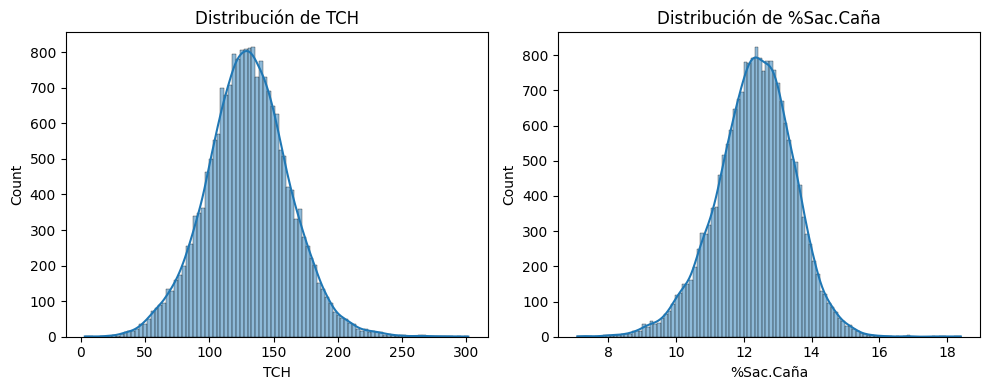

In [15]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df_reg["TCH"], kde=True)
plt.title("Distribución de TCH")

plt.subplot(1,2,2)
sns.histplot(df_reg["%Sac.Caña"], kde=True)
plt.title("Distribución de %Sac.Caña")

plt.tight_layout()
plt.show()

A partir de los histogramas de las variables objetivo, se observa que tanto TCH como %Sac.Caña presentan distribuciones aproximadamente normales.

En el caso de TCH, se evidencia una mayor dispersión y la presencia de valores extremos hacia la derecha, lo que indica la existencia de parcelas con rendimientos significativamente altos.

Por otro lado, la variable %Sac.Caña presenta una distribución más concentrada, lo que sugiere una mayor estabilidad en la calidad del cultivo en comparación con la cantidad producida.

Este comportamiento es consistente con el contexto del negocio, donde factores agronómicos y climáticos pueden generar mayor variabilidad en la producción que en la calidad del cultivo.

## Análisis de valores atípicos

Se utilizaron diagramas de caja (boxplots) para identificar la presencia de valores atípicos en las variables objetivo.

Se evidenció la existencia de outliers tanto en **TCH** como en **%Sac.Caña**, siendo más pronunciados en la variable TCH.

Sin embargo, estos valores no fueron eliminados, ya que en el contexto agrícola pueden representar condiciones reales de alta o baja productividad. Su eliminación podría implicar la pérdida de información relevante para el modelo.

Por lo tanto, se decidió conservar estos valores para mantener la representatividad del dataset.

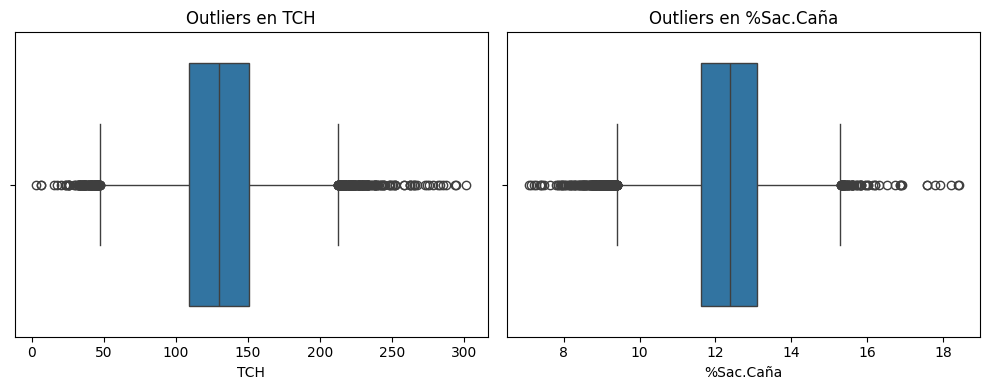

In [16]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=df_reg["TCH"])
plt.title("Outliers en TCH")

plt.subplot(1,2,2)
sns.boxplot(x=df_reg["%Sac.Caña"])
plt.title("Outliers en %Sac.Caña")

plt.tight_layout()
plt.show()

A partir del análisis mediante diagramas de caja (boxplots), se identificó la presencia de valores atípicos en las variables TCH y %Sac.Caña.

En el caso de TCH, se observa una mayor cantidad de valores extremos, lo cual es consistente con la variabilidad natural en la productividad de los cultivos, donde ciertas parcelas pueden alcanzar rendimientos significativamente superiores.

Para la variable %Sac.Caña, también se evidencian valores atípicos, aunque en menor proporción.

Dado el contexto del negocio, se decidió no eliminar estos valores, ya que pueden representar condiciones reales del cultivo y su eliminación podría implicar la pérdida de información relevante para el modelo.

## Análisis de correlación

Se construyó una matriz de correlación para evaluar la relación entre las variables numéricas del dataset.

Se identificó una alta correlación (0.95) entre **Area Neta** y **TonUltCorte**, lo cual indica redundancia de información. Como resultado, se decidió eliminar la variable **Area Neta**, conservando **TonUltCorte** por ser más representativa del rendimiento del cultivo.

Adicionalmente, se observaron correlaciones moderadas entre algunas variables y las variables objetivo, lo cual respalda su relevancia para el modelo.

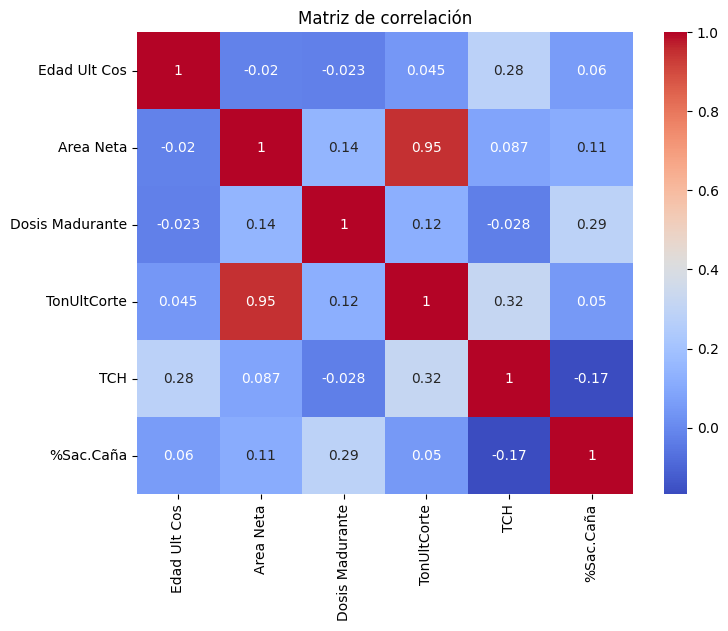

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df_reg.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

A partir de la matriz de correlación, se identificaron relaciones relevantes entre las variables numéricas. Se destaca una alta correlación (0.95) entre Area Neta y TonUltCorte, lo que indica un problema de multicolinealidad, ya que ambas variables contienen información redundante.

Para evitar este problema, se decidió eliminar una de las dos variables, manteniendo TonUltCorte, dado que representa de forma más directa el rendimiento histórico del cultivo.

Asimismo, se identificaron relaciones moderadas entre variables como Edad Ult Cos y TCH, y entre Dosis Madurante y %Sac.Caña, lo cual respalda su inclusión en el modelo.

## Análisis de multicolinealidad (VIF)

Se calculó el Factor de Inflación de la Varianza (VIF) con el objetivo de evaluar la presencia de multicolinealidad entre las variables numéricas.

Los resultados muestran que todas las variables presentan valores de VIF inferiores a 5, lo que indica que no existe multicolinealidad significativa entre los predictores.

Esto confirma que las variables seleccionadas aportan información independiente, lo cual es deseable para la estabilidad y confiabilidad del modelo.

In [18]:
df_reg = df_reg.drop(columns=["Area Neta"])

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# solo variables numéricas
X = df_reg.select_dtypes(include=[np.number]).drop(columns=["TCH", "%Sac.Caña"])

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data

,Variable,VIF
0,Edad Ult Cos,2.939479
1,Dosis Madurante,2.003265
2,TonUltCorte,2.291698


Para evaluar la presencia de multicolinealidad entre las variables numéricas, se calculó el Factor de Inflación de la Varianza (VIF).

Los resultados muestran que todas las variables presentan valores de VIF inferiores a 5, lo que indica que no existe multicolinealidad significativa entre los predictores.

Esto confirma que las variables seleccionadas aportan información independiente al modelo, lo cual es deseable para garantizar la estabilidad y confiabilidad de las estimaciones.

A lo largo del análisis exploratorio de datos, se realizó un proceso estructurado que incluyó la selección de variables basada en el conocimiento del negocio, el tratamiento de valores faltantes, el análisis de distribuciones, la identificación de valores atípicos y la evaluación de relaciones entre variables.

Se identificaron variables con alto porcentaje de datos faltantes, las cuales fueron eliminadas para mejorar la calidad del conjunto de datos. Asimismo, se aplicaron técnicas de imputación diferenciadas según el tipo de variable.

El análisis de distribuciones permitió evidenciar comportamientos coherentes con el contexto agrícola, mientras que el análisis de correlación y VIF permitió validar la independencia entre variables y evitar problemas de multicolinealidad.

En conjunto, este proceso garantiza que los datos están en condiciones adecuadas para la construcción de modelos predictivos en las siguientes etapas del laboratorio.